#Turma
---
11DTSR

----
#Disciplina
---
Cognitive Environments

---



# Bibliotecas úteis

In [1]:
#
import numpy as np
from google.cloud import bigquery
from google.oauth2 import service_account


ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Relatórios
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Autenticação do Colab com o Bigquery

In [ ]:
from google.colab import auth
auth.authenticate_user()

#Identificação do Projeto GCP

In [ ]:
#@markdown Informe o ID do projeto
project_id = "astute-office-462719-c4" #@param {type:"string"}

# **Parte 01 - Análises Big Data na nuvem**
---

  1. Utilizando apenas ferramentas na nuvem, faça análise de dados "GIGANTES" em seu ambiente utilizando um Notebook Python. Não serão aceitas entregas que não sejam via Notebook.
    
  2. Avalie as corridas dos táxis amarelos de NY e responda:
  * Em 2017, como foram as quantidades de corridas de acordo com o dia da semana? (1,0)
  * Em 2017, como foram os valores das corridas de acordo com o dia da semana? (1,0)
  * Em 2017, como foram os valores das corridas de acordo com a quantidade de passageiros? (0,50)
  * Em 2017, como foram as gorjetas de acordo com o dia da semana? (0,50)

  3. Ainda neste conjunto de dados, avalie a evolução ano a ano de 2017 até 2021 (5 anos)
  * Total absoluto de corridas (1,0)
  * Total relativo de corridas por dia da semana (1,0)
  * Total relativo de corridas por período do dia  (1,0)
  * (pesquisar sobre extração de hora) Total: 6,0
  
  4. Todas as análises devem ser em formato tabular e gráfico.



## Análise Exploratória de Dados
Identificação dos tipos de dados, valores nulos e amostra de registros.


In [ ]:
#instanciar o bigquery
bqClient = bigquery.Client(project=project_id)

###Funções úteis para formatação nos gráficos

In [ ]:

def formato_milhoes(x, pos=None):
    return f'${x/1000000:.1f}M'

def formata_porcentagem(x, pos=None):
    return f'{x:.2f}%'

def formata_milhoes_milhares(valores):
    for v in valores:
      if v >= 1000000:
          labels_valores.append(f'${v/1000000:.1f}M') # Se for maior que 1 milhão, usa M
      else:
          labels_valores.append(f'${v/1000:.1f}K')    # Se for menor, usa K (Milhares)
    return labels_valores

###Avalie as corridas dos táxis amarelos de NY

####**Em 2017, como foram as quantidades de corridas de acordo com o dia da semana?**

Executando a consulta diretamente nos servidores do BigQuery...

--- Resultado Tabular: Quantidade de corridas por Dia da Semana (2017) ---


,dia_semana_num,dia_da_semana,qtde_corridas
0,1,1 - Domingo,14996643
1,2,2 - Segunda-feira,14597337
2,3,3 - Terça-feira,15824822
3,4,4 - Quarta-feira,16744059
4,5,5 - Quinta-feira,17070436
5,6,6 - Sexta-feira,17388232
6,7,7 - Sábado,16878787


Total de corridas de 2017: 113500316


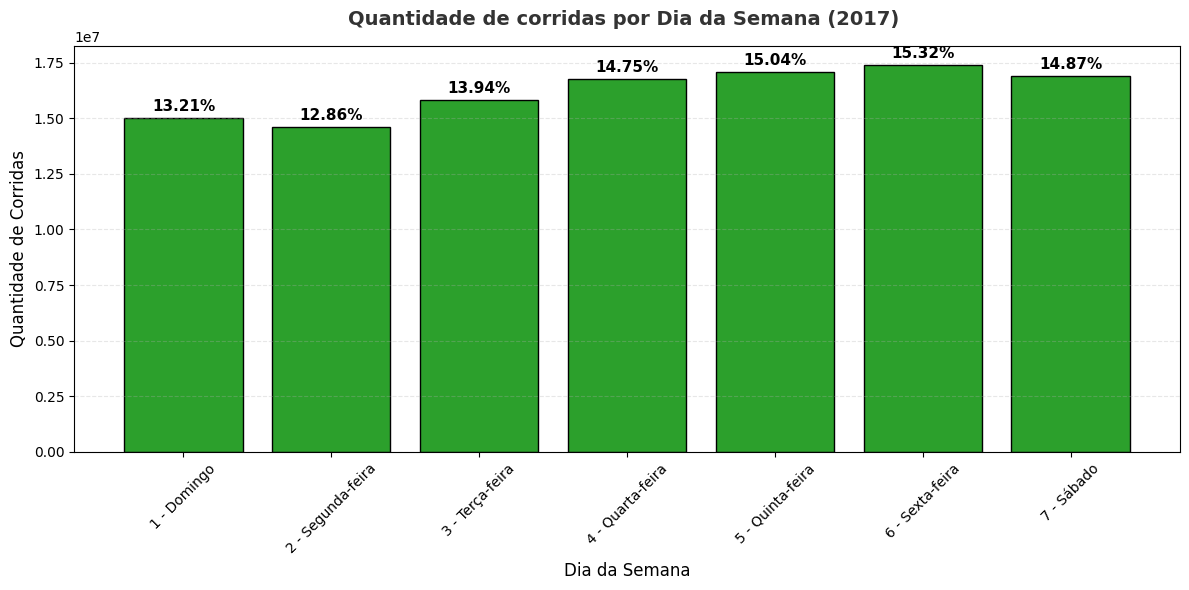

In [ ]:


# Query usando a sintaxe nativa do BigQuery (Standard SQL)

sql_quantidade_2017 = """
    SELECT
        EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        count(*) AS qtde_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY dia_semana_num, dia_da_semana
    ORDER BY dia_semana_num
"""

print("Executando a consulta diretamente nos servidores do BigQuery...")

# Executa a query e converte direto para Pandas
df_Quantidade = bqClient.query(sql_quantidade_2017).to_dataframe()

# Exibe a tabela
print("\n--- Resultado Tabular: Quantidade de corridas por Dia da Semana (2017) ---")
display(df_Quantidade)

# Pegando o total de corridas
total = df_Quantidade['qtde_corridas'].sum()
print(f"Total de corridas de 2017: {total}")

# Calcula a porcentagem para cada dia
percentuais = (df_Quantidade['qtde_corridas'] / total) * 100



plt.figure(figsize=(12, 6))

# CRIANDO OS Labels FORMATADOS (ex: 15.24%)
labels_percentuais = [f'{p:.2f}%' for p in percentuais]

bars = plt.bar(df_Quantidade['dia_da_semana'], df_Quantidade['qtde_corridas'], color='#2ca02c', edgecolor='black')

plt.title('Quantidade de corridas por Dia da Semana (2017) ', fontsize=14, pad=15, fontweight='bold', color='#333333')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Quantidade de Corridas', fontsize=12)

# Rotaciona os nomes dos dias
plt.xticks(rotation=45)


plt.bar_label(bars, labels=labels_percentuais, padding=3, fontsize=11, color='black', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)


# Ajusta o layout e plota
plt.tight_layout()
plt.show()


####**Em 2017, como foram os valores das corridas de acordo com o dia da semana?**

Executando a consulta diretamente nos servidores do BigQuery...

--- Resultado Tabular: Valores Arrecadados por Dia da Semana (2017) ---


,dia_semana_num,dia_da_semana,valor_corridas
0,1,1 - Domingo,243896728.750000000
1,2,2 - Segunda-feira,240518668.340000000
2,3,3 - Terça-feira,258555164.270000000
3,4,4 - Quarta-feira,278823744.140000000
4,5,5 - Quinta-feira,287889819.160000000
5,6,6 - Sexta-feira,287646492.820000000
6,7,7 - Sábado,257563616.630000000


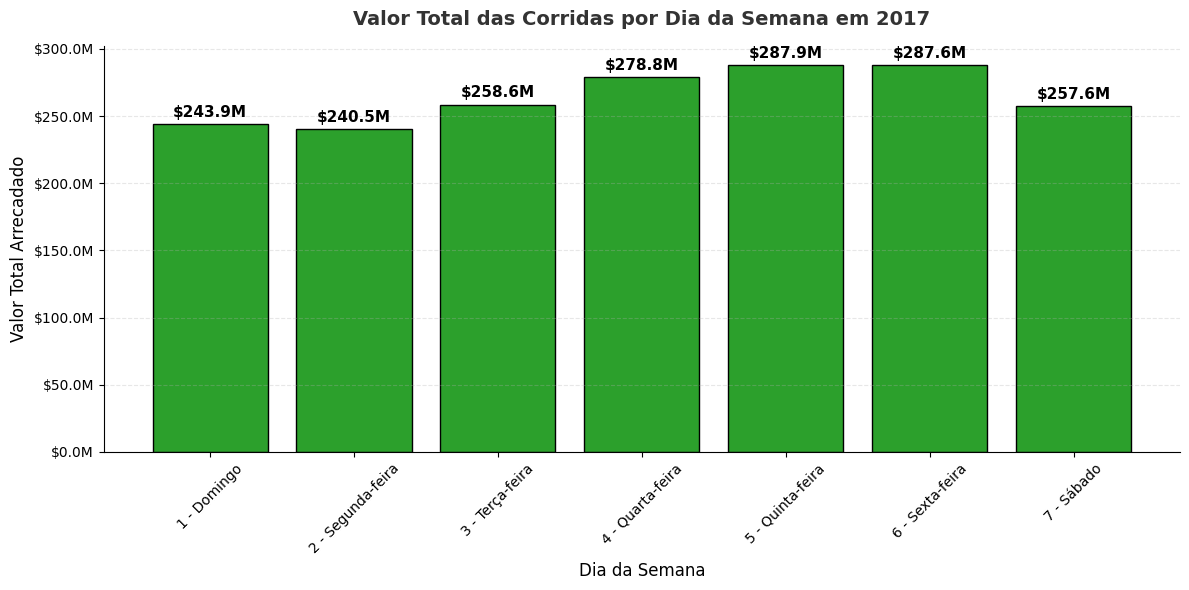

In [ ]:


# Query usando a sintaxe nativa do BigQuery (Standard SQL)

sql_valores_2017 = """
    SELECT
        EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        ROUND(SUM(total_amount), 2) AS valor_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY dia_semana_num, dia_da_semana
    ORDER BY dia_semana_num
"""

print("Executando a consulta diretamente nos servidores do BigQuery...")

# Executa a query e converte direto para Pandas
df_Quantidade = bqClient.query(sql_valores_2017).to_dataframe()

# Exibe a tabela
print("\n--- Resultado Tabular: Valores Arrecadados por Dia da Semana (2017) ---")
display(df_Quantidade)


plt.figure(figsize=(12, 6))

bars = plt.bar(df_Quantidade['dia_da_semana'], df_Quantidade['valor_corridas'], color='#2ca02c', edgecolor='black')

plt.title('Valor Total das Corridas por Dia da Semana em 2017', fontsize=14, pad=15, fontweight='bold', color='#333333')
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Valor Total Arrecadado', fontsize=12)

# Rotaciona os nomes dos dias
plt.xticks(rotation=45)


plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_milhoes))

# Rótulos nas barras
labelsValores = [f'${v/1000000:.1f}M' for v in df_Quantidade['valor_corridas']]

plt.bar_label(bars, labels=labelsValores, padding=3, fontsize=11, color='black', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ajusta o layout e plota
plt.tight_layout()
plt.show()



####**Em 2017, como foram os valores das corridas de acordo com a quantidade de passageiros?**

--- Resultado Tabular: Valores Arrecadados por Quantidade de Passageiros (2017) ---


,qtde_passageiros,valor_total
0,0,2746164.750000000
1,1,1309387623.010000000
2,2,281893698.890000000
3,3,79983024.990000000
4,4,38111532.040000000
5,5,88475792.710000000
6,6,54240162.800000000
7,7,18365.300000000
8,8,18136.910000000
9,9,19723.170000000


Total de passageiros de 2017: 1854894234.110000000


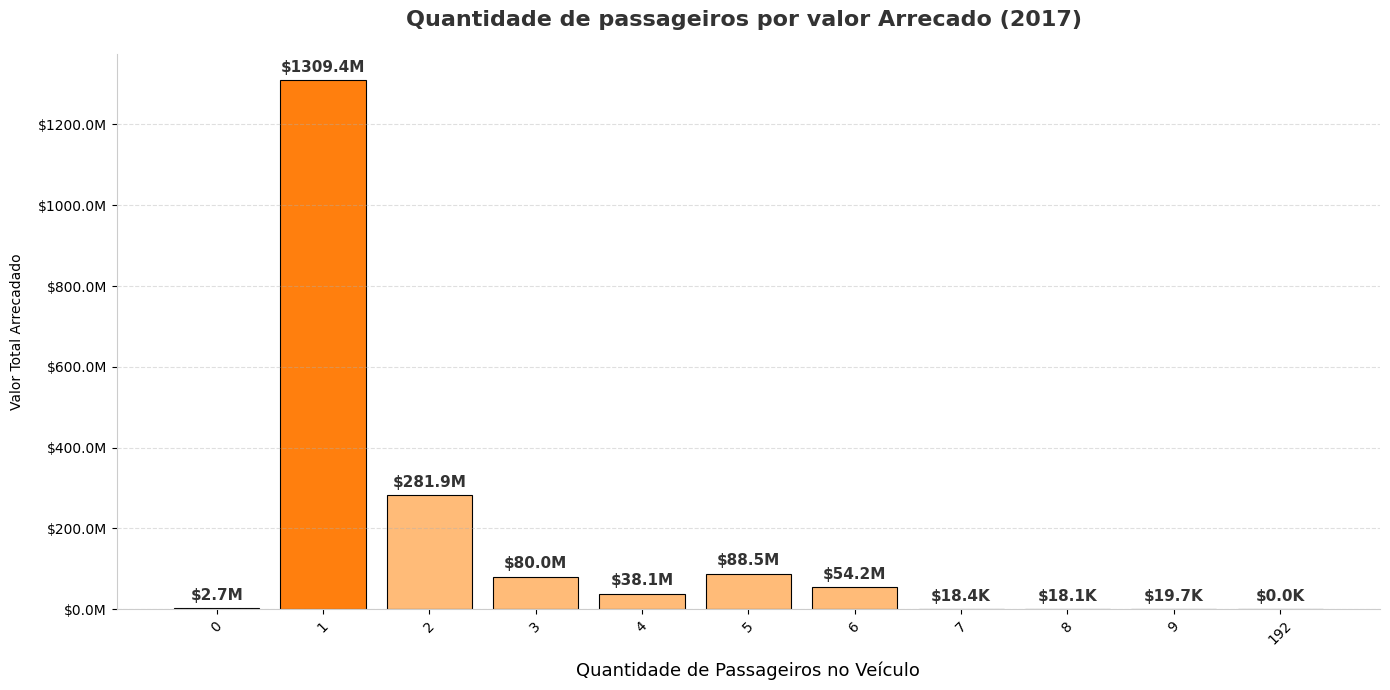

In [ ]:

sql_passageiros = """
    SELECT
        passenger_count AS qtde_passageiros,
        ROUND(SUM(total_amount), 2) AS valor_total
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    WHERE passenger_count IS NOT NULL
    GROUP BY qtde_passageiros
    ORDER BY qtde_passageiros
"""

df_passageiros = bqClient.query(sql_passageiros).to_dataframe()
print("--- Resultado Tabular: Valores Arrecadados por Quantidade de Passageiros (2017) ---")

display(df_passageiros)

# Pegando o total de corridas
total = df_passageiros['valor_total'].sum()
print(f"Total de passageiros de 2017: {total}")

# Calcula a porcentagem para cada dia
percentuais = (df_passageiros['valor_total'] / total) * 100

# Encontra qual é o valor máximo para dar destaque na cor
valor_maximo = df_passageiros['valor_total'].max()

#conversão para melhorar a visualização do gráfico
df_passageiros['qtde_passageiros'] = df_passageiros['qtde_passageiros'].astype(str)

# Cria uma lista de cores: Laranja forte para o maior, Laranja claro para os demais
cores = ['#ff7f0e' if valor == valor_maximo else '#ffbb78' for valor in df_passageiros['valor_total']]


plt.figure(figsize=(14,7))

# CRIANDO OS Labels FORMATADOS (ex: 15.24%)
labels_percentuais = [f'{p:.2f}%' for p in percentuais]

bars = plt.bar(df_passageiros['qtde_passageiros'], df_passageiros['valor_total'], color=cores, edgecolor='black', linewidth = 0.8)

plt.title('Quantidade de passageiros por valor Arrecado (2017) ', fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Quantidade de Passageiros no Veículo', fontsize=13, labelpad=10)
plt.ylabel('Valor Total Arrecadado', fontsize=10, labelpad = 10)

# Rotaciona os nomes dos dias
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_milhoes))



# Labels Dinâmicos no topo das barras (Milhões ou Milhares)
labels_valores = []

labels_valores = formata_milhoes_milhares(df_passageiros['valor_total'])

plt.bar_label(bars, labels=labels_valores, padding=4, fontsize=11, color='#333333', fontweight='bold')

# Estilização final (Removendo bordas desnecessárias)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



####**Em 2017, como foram as gorjetas de acordo com o dia da semana?**

--- Resultado Tabular: Gorjetas arrecadadas por dias da semana (2017) ---


,dia_semana_num,dia_da_semana,gorjetas
0,1,1 - Domingo,26225824.790000000
1,2,2 - Segunda-feira,27236752.200000000
2,3,3 - Terça-feira,29761261.010000000
3,4,4 - Quarta-feira,32330591.500000000
4,5,5 - Quinta-feira,33334264.430000000
5,6,6 - Sexta-feira,32415068.720000000
6,7,7 - Sábado,27230300.600000000


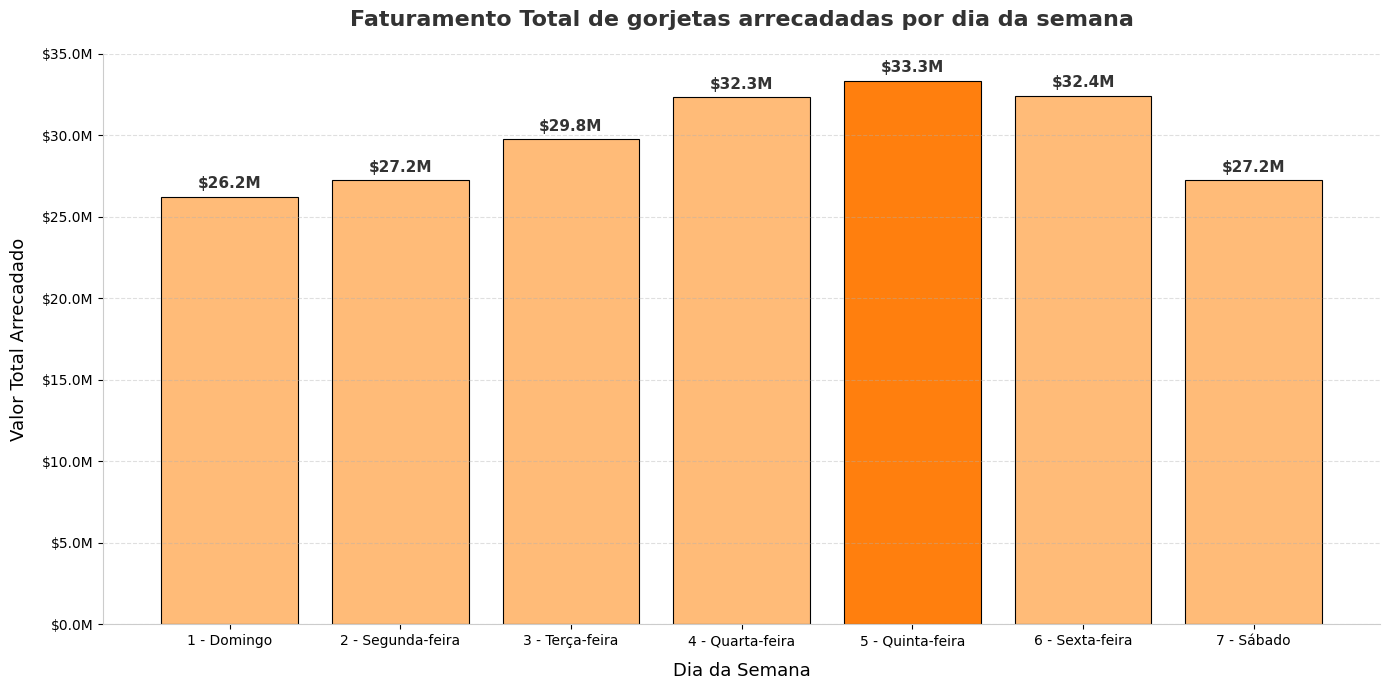

In [ ]:

sql_gorjetas = """
    SELECT
      EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        round(sum(tip_amount), 2) AS gorjetas
  FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY dia_semana_num, dia_da_semana
    ORDER BY dia_semana_num
"""

df_gorjetas = bqClient.query(sql_gorjetas).to_dataframe()
print("--- Resultado Tabular: Gorjetas arrecadadas por dias da semana (2017) ---")
display(df_gorjetas)




# Encontra qual é o valor máximo para dar destaque na cor
valor_maximo = df_gorjetas['gorjetas'].max()

# Cria uma lista de cores: Laranja forte para o maior, Laranja claro para os demais
cores = ['#ff7f0e' if valor == valor_maximo else '#ffbb78' for valor in df_gorjetas['gorjetas']]


plt.figure(figsize=(14, 7))

bars = plt.bar(df_gorjetas['dia_da_semana'], df_gorjetas['gorjetas'],
               color=cores, edgecolor='black', linewidth=0.8)

# Títulos e Eixos mais limpos e elegantes
plt.title('Faturamento Total de gorjetas arrecadadas por dia da semana', fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel('Dia da Semana', fontsize=13, labelpad=10)
plt.ylabel('Valor Total Arrecadado', fontsize=13, labelpad=10)


plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_milhoes))

# Labels Dinâmicos no topo das barras (Milhões ou Milhares)
labels_valores = []

labelsValores = formata_milhoes_milhares(df_gorjetas['gorjetas'])
plt.bar_label(bars, labels=labels_valores, padding=4, fontsize=11, color='#333333', fontweight='bold')

# Estilização final (Removendo bordas desnecessárias)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

###**Ainda neste conjunto de dados, avalie a evolução ano a ano de 2017 até 2021 (5 anos)**


####**Total absoluto de corridas**

--- Resultado Tabular: Total absoluto de corridas (2017-2021) ---


,ano,quantidade_corridas
0,2018,102871376
1,2017,113500316
2,2021,30904297
3,2019,84598433
4,2020,24649081


Total de corridas de 2017 a 2021: 356523503


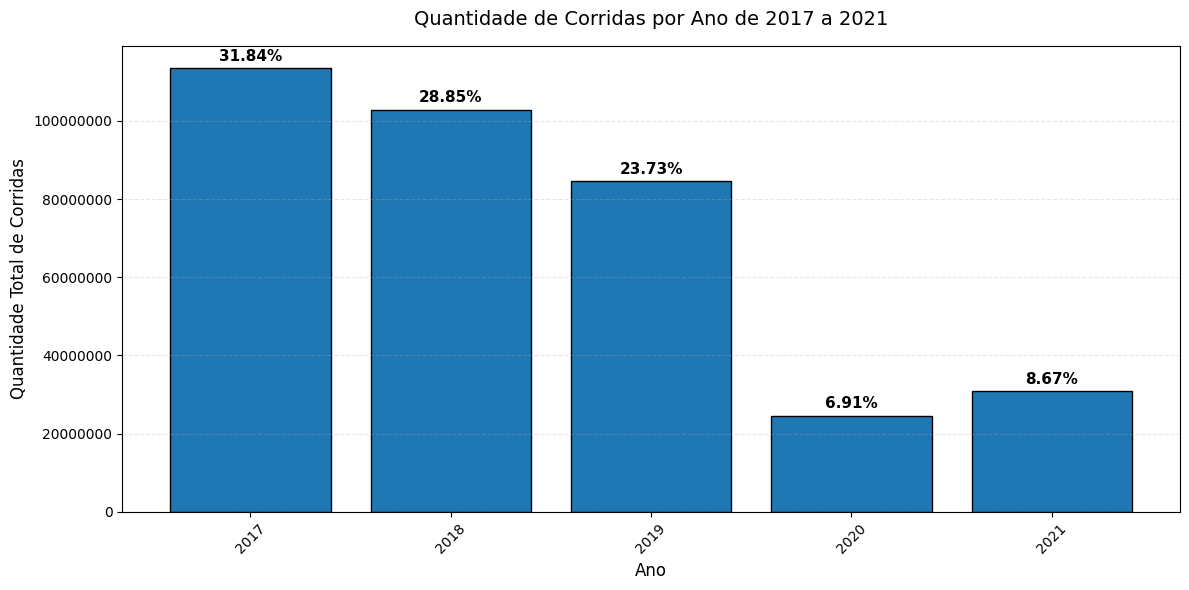

In [ ]:
sql_total_absoluto = """
SELECT
        DATA_FILE_YEAR  AS ano,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY  DATA_FILE_YEAR
UNION ALL
SELECT
        DATA_FILE_YEAR AS ano,
        COUNT(1) AS quantidade_corridas
        FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2018`
    GROUP BY DATA_FILE_YEAR
    UNION ALL
SELECT
       DATA_FILE_YEAR AS ano,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2019`
    GROUP BY DATA_FILE_YEAR
union ALL
SELECT
       DATA_FILE_YEAR AS ano,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2020`
    GROUP BY  DATA_FILE_YEAR
UNION ALL
SELECT
        DATA_FILE_YEAR AS ano,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    GROUP BY  DATA_FILE_YEAR
"""
df_total = bqClient.query(sql_total_absoluto).to_dataframe()
print("--- Resultado Tabular: Total absoluto de corridas (2017-2021) ---")
display(df_total)


# Pegando o total de corridas
total = df_total['quantidade_corridas'].sum()
print(f"Total de corridas de 2017 a 2021: {total}")



# Calcula a porcentagem para cada dia
percentuais = (df_total['quantidade_corridas'] / total) * 100

# Configura o tamanho da figura
plt.figure(figsize=(12, 6))

# Salvamos o gráfico na variável 'bars'
bars = plt.bar(df_total['ano'], df_total['quantidade_corridas'], color='#1f77b4', edgecolor='black')

plt.title('Quantidade de Corridas por Ano de 2017 a 2021', fontsize=14, pad=15)
plt.xlabel('Ano', fontsize=12)


plt.ylabel('Quantidade Total de Corridas', fontsize=12)

# CRIANDO OS Labels FORMATADOS (ex: 15.24%)
labels_percentuais = [f'{p:.2f}%' for p in percentuais]

# ADICIONA OS Labels (PERCENTUAIS) NO TOPO DE CADA BARRA
plt.bar_label(bars, labels=labels_percentuais, padding=3, fontsize=11, color='black', fontweight='bold')

# Rotaciona os nomes dos dias para não sobrepor
plt.xticks(rotation=45)

# Remove a notação científica do eixo Y
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Ajusta o layout e plota
plt.tight_layout()
plt.show()


####**Total relativo de corridas por dia da semana**

In [ ]:
import matplotlib.ticker as mtick

--- Resultado Tabular: Total relativo de corridas (2017-2021) ---


,ano,dia_da_semana,total_absoluto,percentual_relativo
0,2017,1 - Domingo,14996643,13.21
1,2017,2 - Segunda-feira,14597337,12.86
2,2017,3 - Terça-feira,15824822,13.94
3,2017,4 - Quarta-feira,16744059,14.75
4,2017,5 - Quinta-feira,17070436,15.04
5,2017,6 - Sexta-feira,17388232,15.32
6,2017,7 - Sábado,16878787,14.87
7,2018,1 - Domingo,13014785,12.65
8,2018,2 - Segunda-feira,13752966,13.37
9,2018,3 - Terça-feira,14762053,14.35


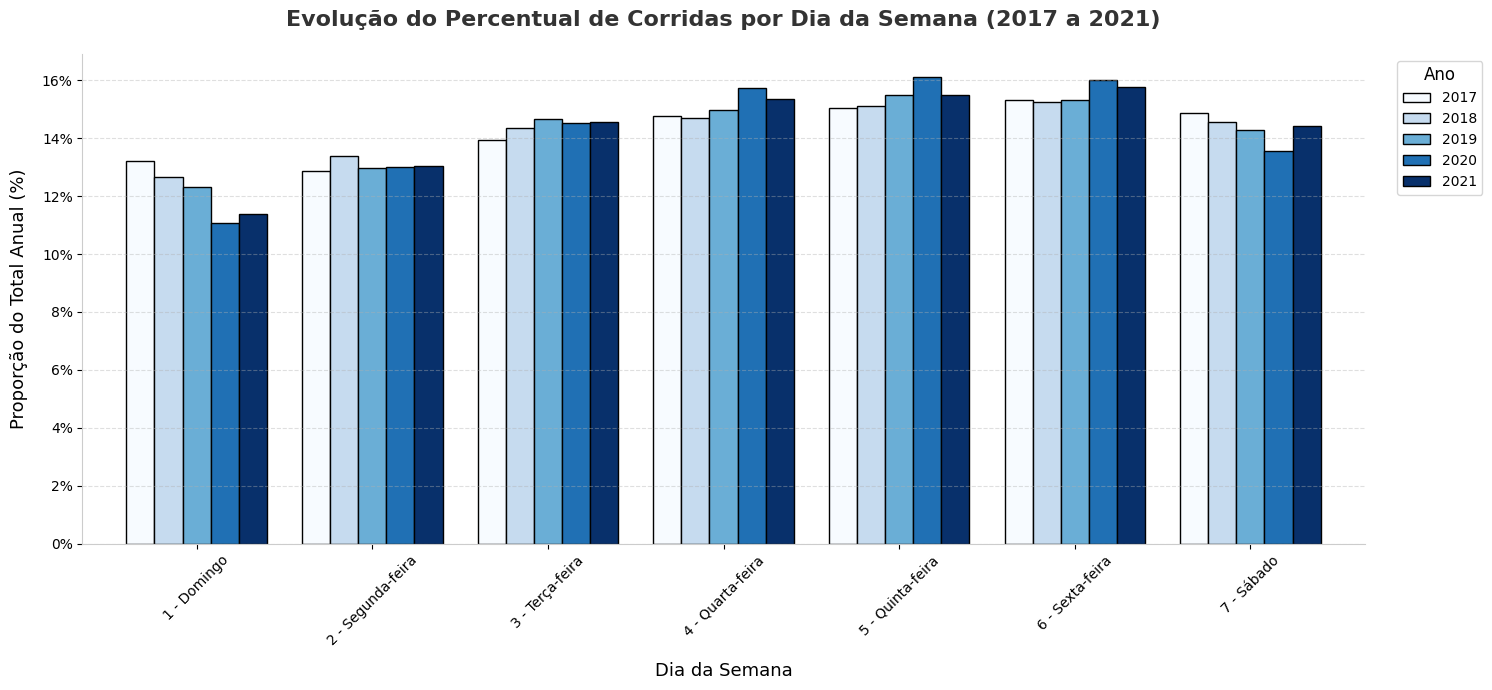

In [ ]:
sql_relativo = """
with relativo_semana as (
SELECT
DATA_FILE_YEAR AS ano,
              EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY ano,  dia_semana_num,  dia_da_semana
UNION ALL
SELECT
DATA_FILE_YEAR AS ano,
      EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        COUNT(1) AS quantidade_corridas
        FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2018`
    GROUP BY ano, dia_semana_num, dia_da_semana
    UNION ALL
SELECT
DATA_FILE_YEAR AS ano,
           EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2019`
    GROUP BY ano , dia_semana_num, dia_da_semana
union ALL
SELECT
DATA_FILE_YEAR AS ano,
          EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2020`
    GROUP BY  ano , dia_semana_num, dia_da_semana
UNION ALL
SELECT
DATA_FILE_YEAR AS ano,
             EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana_num,
        CASE EXTRACT(DAYOFWEEK FROM pickup_datetime)
            WHEN 1 THEN '1 - Domingo'
            WHEN 2 THEN '2 - Segunda-feira'
            WHEN 3 THEN '3 - Terça-feira'
            WHEN 4 THEN '4 - Quarta-feira'
            WHEN 5 THEN '5 - Quinta-feira'
            WHEN 6 THEN '6 - Sexta-feira'
            WHEN 7 THEN '7 - Sábado'
        END AS dia_da_semana,
        COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    GROUP BY ano , dia_semana_num, dia_da_semana
    )

    SELECT
        ano,
        dia_da_semana,
        quantidade_corridas AS total_absoluto,
        ROUND((quantidade_corridas / SUM(quantidade_corridas) OVER (PARTITION BY ano)) * 100, 2) AS percentual_relativo
    FROM relativo_semana
    ORDER BY ano, dia_semana_num
"""
df_evolucao_relativa_dias = bqClient.query(sql_relativo).to_dataframe()
print("--- Resultado Tabular: Total relativo de corridas (2017-2021) ---")
display(df_evolucao_relativa_dias)


# Reestrutura a tabela (Pivot) para o formatodf_evolucao_relativa_dias dias da semana viram as linhas, e cada ano vira uma coluna com os percentuais
df_pivot = df_evolucao_relativa_dias.pivot(index='dia_da_semana', columns='ano', values='percentual_relativo')

# Cria o gráfico de barras agrupadas
# Usamos o colormap 'Blues' para criar um degradê de cores indicando a passagem do tempo
ax = df_pivot.plot(kind='bar', figsize=(15, 7), width=0.8, colormap='Blues', edgecolor='black')

# Textos e Títulos
plt.title('Evolução do Percentual de Corridas por Dia da Semana (2017 a 2021)', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Dia da Semana', fontsize=13, labelpad=10)
plt.ylabel('Proporção do Total Anual (%)', fontsize=13, labelpad=10)

# Formatação do Eixo Y para colocar o símbolo de '%'
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Ajuste da Legenda e Labels
plt.xticks(rotation=45)
# Move a legenda (caixinha dos anos) para fora do gráfico para não cobrir as barras
plt.legend(title='Ano', title_fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left')

# Limpeza visual (Design Executivo)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


####**Total relativo de corridas por período do dia**

--- Resultado Tabular: Total relativo de corridas por Hora (2017-2021) ---


,ano,HORA_DIA,total_absoluto,percentual_relativo
0,2017,0,3836201,3.38
1,2017,1,2789170,2.46
2,2017,2,2021211,1.78
3,2017,3,1461536,1.29
4,2017,4,1131718,1.00
...,...,...,...,...
115,2021,19,1930833,6.25
116,2021,20,1560310,5.05
117,2021,21,1414016,4.58
118,2021,22,1281126,4.15


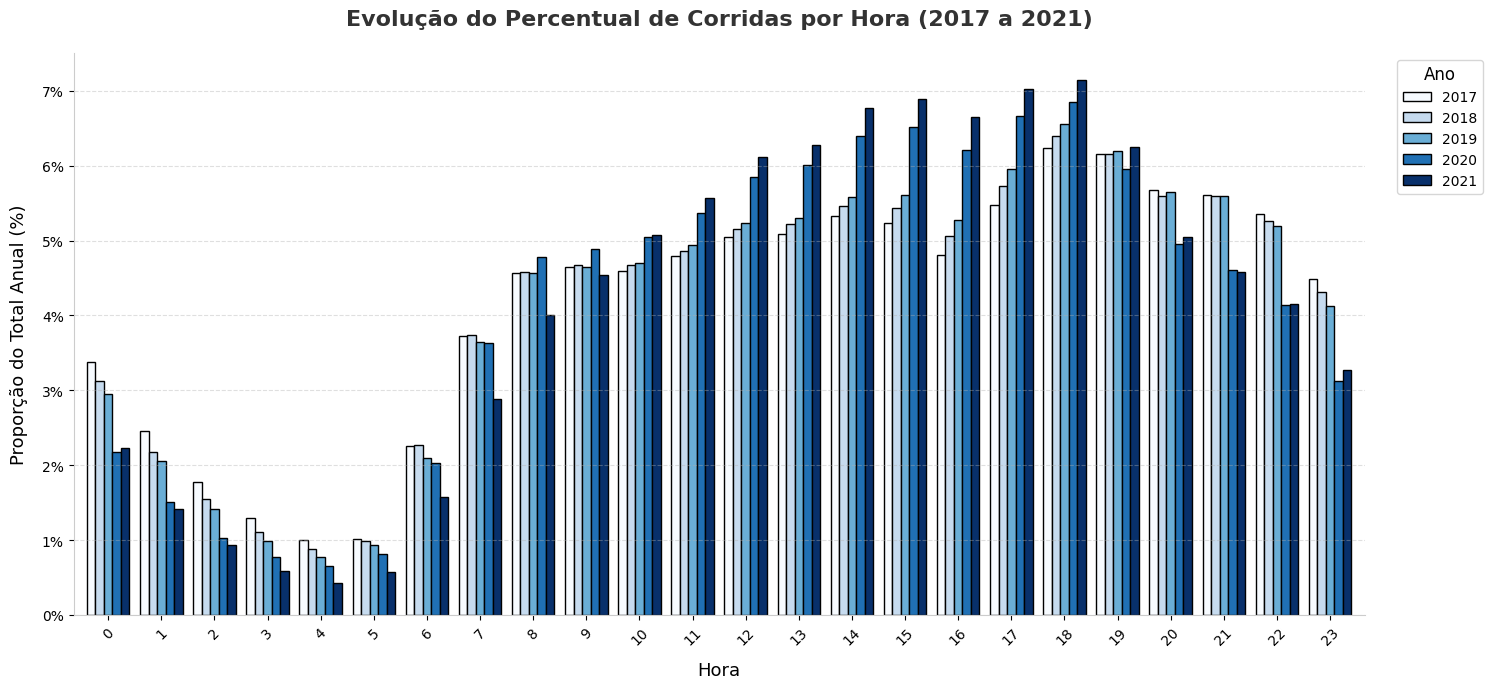

In [ ]:
sql_relativo = """
WITH
  relativo_hora AS (
    SELECT
      DATA_FILE_YEAR AS ano,
      EXTRACT(HOUR FROM pickup_datetime) AS HORA_DIA,
      COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2017`
    GROUP BY ano, HORA_DIA
    UNION ALL
    SELECT
      DATA_FILE_YEAR AS ano,
      EXTRACT(HOUR FROM pickup_datetime) AS HORA_DIA,
      COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2018`
    GROUP BY ano, HORA_DIA
    UNION ALL
    SELECT
      DATA_FILE_YEAR AS ano,
      EXTRACT(HOUR FROM pickup_datetime) AS HORA_DIA,
      COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2019`
    GROUP BY ano, HORA_DIA
    UNION ALL
    SELECT
      DATA_FILE_YEAR AS ano,
      EXTRACT(HOUR FROM pickup_datetime) AS HORA_DIA,
      COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2020`
    GROUP BY ano, HORA_DIA
    UNION ALL
    SELECT
      DATA_FILE_YEAR AS ano,
      EXTRACT(HOUR FROM pickup_datetime) AS HORA_DIA,
      COUNT(1) AS quantidade_corridas
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    GROUP BY ano, HORA_DIA
  )
SELECT
  ano,
  HORA_DIA,
  quantidade_corridas AS total_absoluto,
  ROUND(
    (quantidade_corridas / SUM(quantidade_corridas) OVER (PARTITION BY ano))
      * 100,
    2) AS percentual_relativo
FROM relativo_hora
ORDER BY ano, HORA_DIA

"""
df_evolucao_relativa_dias = bqClient.query(sql_relativo).to_dataframe()
print("--- Resultado Tabular: Total relativo de corridas por Hora (2017-2021) ---")
display(df_evolucao_relativa_dias)




# Reestrutura a tabela (Pivot) para o formato do gráfico
# As horas do dia a viram as linhas, e cada ano vira uma coluna com os percentuais
df_pivot = df_evolucao_relativa_dias.pivot(index='HORA_DIA', columns='ano', values='percentual_relativo')

# Cria o gráfico de barras agrupadas
# Usamos o colormap 'Blues' para criar um degradê de cores indicando a passagem do tempo
ax = df_pivot.plot(kind='bar', figsize=(15, 7), width=0.8, colormap='Blues', edgecolor='black')

# Textos e Títulos
plt.title('Evolução do Percentual de Corridas por Hora (2017 a 2021)', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Hora', fontsize=13, labelpad=10)
plt.ylabel('Proporção do Total Anual (%)', fontsize=13, labelpad=10)

# Formatação do Eixo Y para colocar o símbolo de '%'
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

# Ajuste da Legenda e labels
plt.xticks(rotation=45)
#Move a legenda (caixinha dos anos) para fora do gráfico para não cobrir as barras
plt.legend(title='Ano', title_fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left')

# Limpeza visual (Design Executivo)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## **Parte 02 - Uso de processamento distribuído de nuvem para criar modelos**
---

  1. Criar um modelo de classificação em um notebook Python que, de acordo com os dados da corrida, consiga prever se o motorista irá ganhar alguma gorjeta baseado nos dados de 2021.
    
  2. Fazer pré-processamento em que os dados são separados em Treino/Teste (70/30) e que outliers ou dados incompletos são descartados.
  * Será avaliado o uso de plataforma em nuvem no apoio do processo, logo, o modelo não será avaliado em sua qualidade e assertividade
  
  3. Criar um modelo com o algoritmo e técnica de sua escolha, porém TODOS os dados devem ser utilizados no treinamento.
  * Os dados não podem sair da camada de processamento e ir para a apresentação

  4. Utilizar qualquer estratégia de treinamento de distribuído.

### Bibliotecas para Machine Learning


In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score
import concurrent.futures


####1. Criar um modelo de classificação em um notebook Python que, de acordo com os dados da corrida, consiga prever se o motorista irá ganhar alguma gorjeta baseado nos dados de 2021

### EDA - Análise Exploratória de Dados de 2021

#### Features

##### Identificar Features com maior correlação com o Target

1. Extraindo amostra de 1% do BigQuery para a Correlação...
2. Calculando a Correlação de Pearson...


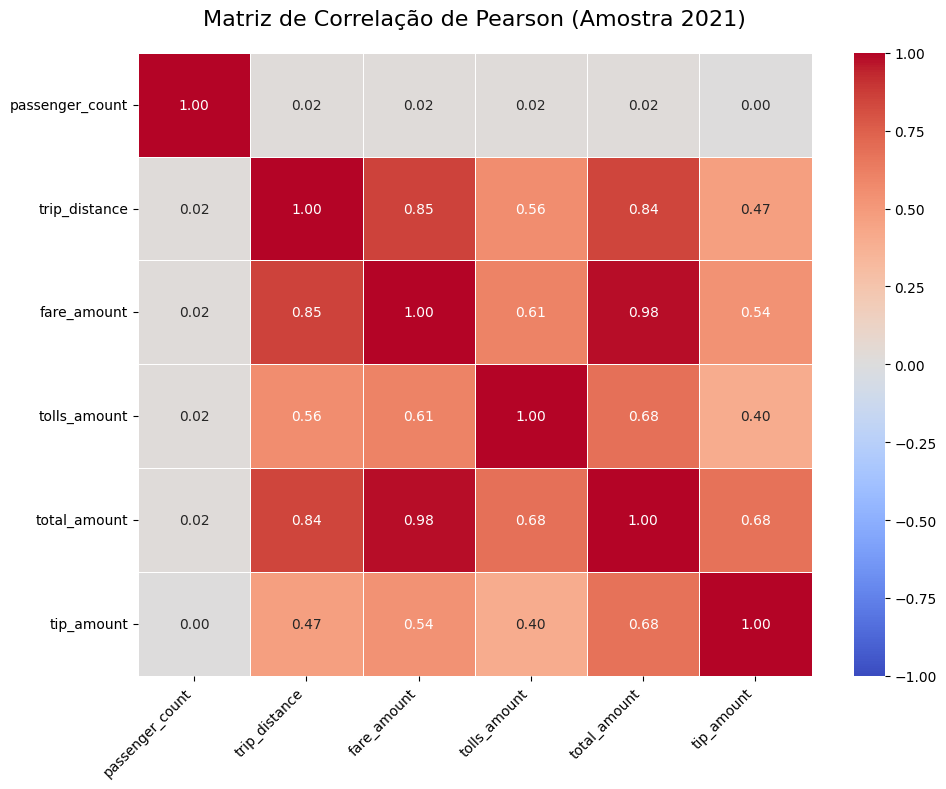

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Extraindo amostra de 1% do BigQuery para a Correlação...")
query_corr = """
    SELECT
        passenger_count, trip_distance, fare_amount, tolls_amount, total_amount, tip_amount
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    WHERE (passenger_count > 0  and passenger_count < 7 ) AND fare_amount > 0 AND trip_distance > 0
      AND RAND() < 0.01 -- Amostra estatisticamente relevante sem travar a memória
"""


df_amostra = bqClient.query(query_corr).to_dataframe().dropna()

print("2. Calculando a Correlação de Pearson...")
matriz_corr = df_amostra.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Matriz de Correlação de Pearson (Amostra 2021)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Removendo Outliers

In [ ]:
print("Calculando os quartis e limites de outliers pelo BigQuery...")

query_outliers = """
    SELECT
     ROUND( APPROX_QUANTILES(fare_amount, 100)[OFFSET(25)] , 2 ) AS fare_q1,
     ROUND(APPROX_QUANTILES(fare_amount, 100)[OFFSET(75)] , 2 ) AS fare_q3,
     ROUND (APPROX_QUANTILES(trip_distance, 100)[OFFSET(25)], 2 )  AS dist_q1,
     ROUND( APPROX_QUANTILES(trip_distance, 100)[OFFSET(75)] , 2 ) AS dist_q3
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    WHERE (passenger_count > 0  and passenger_count < 7 ) AND fare_amount > 0 AND trip_distance > 0
"""

df_quartis = bqClient.query(query_outliers).to_dataframe()

# Cálculo do IQR em Python com base nos resultados do BigQuery
fare_q1, fare_q3 = df_quartis['fare_q1'][0], df_quartis['fare_q3'][0]
dist_q1, dist_q3 = df_quartis['dist_q1'][0], df_quartis['dist_q3'][0]

iqr_fare = fare_q3 - fare_q1
iqr_dist = dist_q3 - dist_q1

# Definindo os limites máximos (Não precisamos de limite mínimo porque já filtramos > 0)
limite_sup_fare =float(fare_q3 ) + 1.5 * float(iqr_fare)
limite_sup_dist = float(dist_q3) + 1.5 * float(iqr_dist)

print(f"Limites Estatísticos (IQR) estabelecidos:")
print(f" -> Tarifa máxima permitida: ${limite_sup_fare:.2f}")
print(f" -> Distância máxima permitida: {limite_sup_dist:.2f}  km ")

Calculando os quartis e limites de outliers pelo BigQuery...
Limites Estatísticos (IQR) estabelecidos:
 -> Tarifa máxima permitida: $25.25
 -> Distância máxima permitida: 6.32  km 


### Machine Learning

#### Treino

In [ ]:

# Vamos dividir o processamento em 4 núcleos (Processos paralelos)
NUM_WORKERS = 2

print("1. Iniciando o Processamento Distribuído Manual e treinamento do modelo...")

def treinar_worker(chunk_id):
    """
    Função MAP: Cada processo executa esta função isoladamente.
    Ele extrai apenas a sua fatia de dados usando uma função matemática (MOD) para não sobrecarregar a memória.
    """
    query_treino = f"""
        SELECT
            passenger_count,
            trip_distance,
            fare_amount,
            tolls_amount,
            EXTRACT(HOUR FROM pickup_datetime) AS hora_corrida,
            EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana,
            IF(tip_amount > 0, 1, 0) as gorjeta
        FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
        WHERE (passenger_count > 0  and passenger_count < 7 ) 
          AND fare_amount > 0 AND fare_amount <= {limite_sup_fare}
          AND trip_distance > 0 AND trip_distance <= {limite_sup_dist}
          AND MOD(ABS(FARM_FINGERPRINT(CAST(pickup_datetime AS STRING))), 10) < 7
          AND MOD(ABS(FARM_FINGERPRINT(CAST(dropoff_datetime AS STRING))), {NUM_WORKERS}) = {chunk_id}
    """

    # Executa a query e garante que todos os dados são lidos como números nativos (float)
    df_chunk = bqClient.query(query_treino).to_dataframe().dropna().astype(float)

    X_treino = df_chunk[["passenger_count", "trip_distance", "fare_amount", "tolls_amount", "hora_corrida", "dia_semana"]]
    y_treino = df_chunk["gorjeta"]

    # Treinamento
    modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
    modelo.fit(X_treino, y_treino)

    print(f" -> Worker {chunk_id} treinou com {len(df_chunk)} registros limpos.")
    return modelo


1. Iniciando o Processamento Distribuído Manual e treinamento do modelo...


In [ ]:

# --- EXECUÇÃO PARALELA ---
floresta_manual = []
with concurrent.futures.ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
    resultados = executor.map(treinar_worker, range(NUM_WORKERS))
    for arvore in resultados:
        if arvore is not None:
            floresta_manual.append(arvore)

 -> Worker 0 treinou com 8765815 registros limpos.
 -> Worker 1 treinou com 8772153 registros limpos.


##### Teste

In [ ]:
# ---------------------------------------------------------
# 3. TESTE E AVALIAÇÃO (Votação da Floresta) 30%
# ---------------------------------------------------------
query_teste = f"""
    SELECT
        passenger_count,
        trip_distance,
        fare_amount,
        tolls_amount,
        EXTRACT(HOUR FROM pickup_datetime) AS hora_corrida,
        EXTRACT(DAYOFWEEK FROM pickup_datetime) AS dia_semana,
        IF(tip_amount > 0, 1.0, 0.0) as gorjeta
    FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2021`
    WHERE (passenger_count > 0  and passenger_count < 7 ) 
      AND fare_amount > 0 AND fare_amount <= {limite_sup_fare}
      AND trip_distance > 0 AND trip_distance <= {limite_sup_dist}
      -- Split Teste
      AND MOD(ABS(FARM_FINGERPRINT(CAST(pickup_datetime AS STRING))), 10) >= 7
"""
df_teste = bqClient.query(query_teste).to_dataframe().dropna().astype(float)

X_teste = df_teste[["passenger_count", "trip_distance", "fare_amount", "tolls_amount", "hora_corrida", "dia_semana"]]
y_teste = df_teste["gorjeta"]

##### Previsões

In [ ]:
previsoes_todas_arvores = np.array([arvore.predict(X_teste) for arvore in floresta_manual])
previsao_final = (previsoes_todas_arvores.sum(axis=0) >= (NUM_WORKERS / 2)).astype(int)
probabilidades_finais = previsoes_todas_arvores.mean(axis=0)

acuracia = accuracy_score(y_teste, previsao_final)
auc = roc_auc_score(y_teste, probabilidades_finais)

print("="*40)
print(" RESULTADO DO MODELO MANUAL (SEM OUTLIERS)")
print("="*40)
print(f"Área sob a curva ROC (AUC): {auc:.4f}")
print(f"Acurácia Final:             {acuracia * 100:.2f}%")
print("="*40)

 RESULTADO DO MODELO MANUAL (SEM OUTLIERS)
Área sob a curva ROC (AUC): 0.5071
Acurácia Final:             74.92%
